# EA FC 24 DATASET

*Miquel Requena Pont*   NIU: 1750324

*Filip Pablo Betanski Szubartowski*   NIU: 1745825

*Joan Gimbert Gallinad*   NIU: 1751932


#**PCA**

1. Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

We need to import the usual libraries: pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for plotting, and sklearn for PCA and scaling.

2. Load the dataset

In [ ]:
players = pd.read_csv('/content/male_players.csv')

3. Preprocessing

  3.1 Drop rows with missing values (in this case there are no much missing values, but this process seems essential for a complete PCA, remember that we cannot handle NaNs.).


In [ ]:
data_clean = players.dropna()
m,n = data_clean.shape
print("# Samples: ", m)
print("# Features: ", n)

# Samples:  0
# Features:  109


As we see, there are not enough imformations to continue with the proces, so we need to fill out the row, with new information related to each player.

  3.2 Select numerical features (excluding target)

In [ ]:
numerical_data = players.select_dtypes(include=['int64', 'float64'])

numerical_data = numerical_data.fillna(numerical_data.mean(numeric_only=True))

numerical_data.head()

,player_id,fifa_version,fifa_update,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
0,231747,24.0,2.0,91.0,94.0,181500000.0,230000.0,24.0,182.0,75.0,...,88.0,26.0,34.0,32.0,13.0,5.0,7.0,11.0,6.0,37.028164
1,239085,24.0,2.0,91.0,94.0,185000000.0,340000.0,22.0,195.0,94.0,...,87.0,38.0,47.0,29.0,7.0,14.0,13.0,11.0,7.0,37.028164
2,192985,24.0,2.0,91.0,91.0,103000000.0,350000.0,32.0,181.0,75.0,...,88.0,66.0,70.0,53.0,15.0,13.0,5.0,10.0,13.0,37.028164
3,158023,24.0,2.0,90.0,90.0,41000000.0,23000.0,36.0,169.0,67.0,...,96.0,20.0,35.0,24.0,6.0,11.0,15.0,14.0,8.0,37.028164
4,165153,24.0,2.0,90.0,90.0,51000000.0,95000.0,35.0,185.0,81.0,...,90.0,43.0,24.0,18.0,13.0,11.0,5.0,5.0,7.0,37.028164


In [ ]:
target = 'overall'
X = numerical_data.drop(columns=[target])
y = numerical_data[target]


4. PCA computation and Standardize the data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components= 10)
X_pca = pca.fit_transform(X_scaled)
pca.fit(X_pca)

NameError: name 'StandardScaler' is not defined

5. Explained variance

  5.1 Plot variance explained

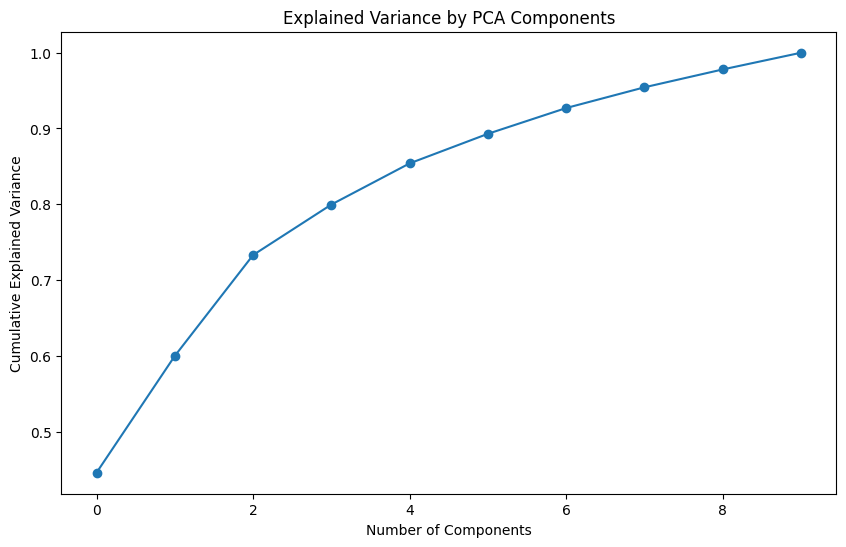

In [ ]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.show()


  5.2 Bar plot of individual variances

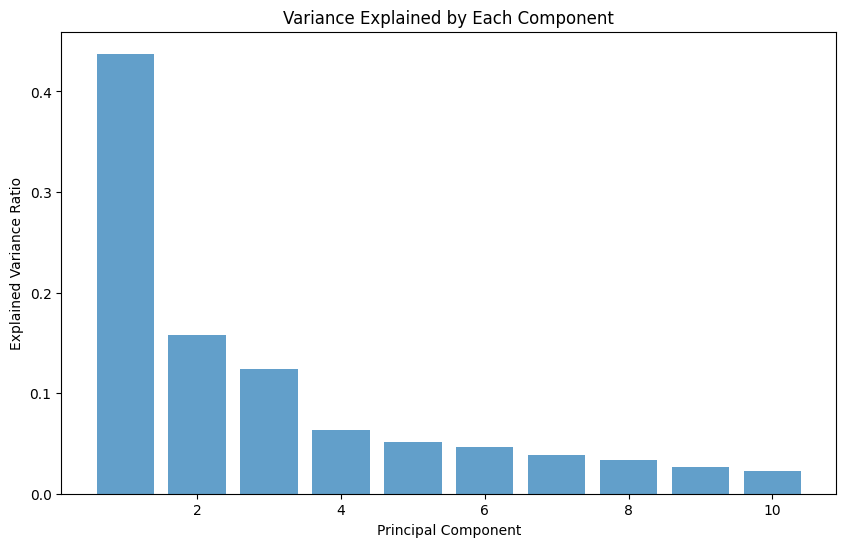


These are the calculated components: 
 [[ 1.00000000e+00 -1.49502600e-16  1.59090176e-16  5.47980990e-17
   2.06710142e-16 -6.42518169e-17  3.12892962e-17  6.13069420e-17
  -2.51652949e-17 -2.67004783e-17]
 [ 1.49502600e-16  1.00000000e+00 -2.05391260e-15  7.77156117e-16
  -3.33066907e-16  5.55111512e-17  9.71445147e-17 -1.66533454e-16
  -8.32667268e-17 -6.93889390e-17]
 [-1.59090176e-16  2.33146835e-15  1.00000000e+00  4.85722573e-17
   5.27355937e-16 -1.94289029e-16  7.63278329e-17  1.66533454e-16
  -1.17961196e-16  1.28369537e-16]
 [-5.47980990e-17 -6.38378239e-16  2.56739074e-16  1.00000000e+00
   3.48332474e-15  8.25728375e-16  2.91433544e-16  2.28983499e-16
  -1.19175503e-15 -1.17787724e-15]
 [-2.06710142e-16  4.44089210e-16 -4.99600361e-16 -3.56659147e-15
   1.00000000e+00  3.09474668e-15  2.49800181e-16  3.88578059e-16
  -2.49800181e-16 -0.00000000e+00]
 [ 6.42518169e-17 -1.94289029e-16  1.11022302e-16 -8.22258928e-16
  -3.08086889e-15  1.00000000e+00 -3.69496100e-16  1.096345

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each Component')
plt.show()
print("\nThese are the calculated components: \n", pca.components_) # The PCA object now contains useful information in its attributes. components_ stores the principal components calculated
print("\nThe components we have found, explain the following percentage of variance: \n", pca.explained_variance_ratio_)

We will select only the first three components because the others don't provide us enough information.


6. Visualizing players in PC space

  6.1 Biplot

In [ ]:
Xnew = pca.transform(X_pca)
print("\nOriginal size of our dataset: ", X_pca.shape)
print("\nReduced size of our dataset: ", Xnew.shape)



Original size of our dataset:  (180021, 10)

Reduced size of our dataset:  (180021, 10)


The biplot shows both players and variable directions. Longer arrows indicate stronger contribution of a variable to the principal components.

In [ ]:
def classify_players(overall_series):
    categories = []
    for value in overall_series:
        if value >= 85:
            categories.append('World Class')
        elif value >= 75:
            categories.append('Top Player')
        elif value >= 65:
            categories.append('Normal Player')
        else:
            categories.append('Bad Player')
    return np.array(categories)

First, we create a function to classify the data and establish the categories to define the classifier. We set four categories: Word Class (≥ 85), Top Player (≥ 75), Normal Player (≥ 65), and "Bad Players" for the rest of the players.

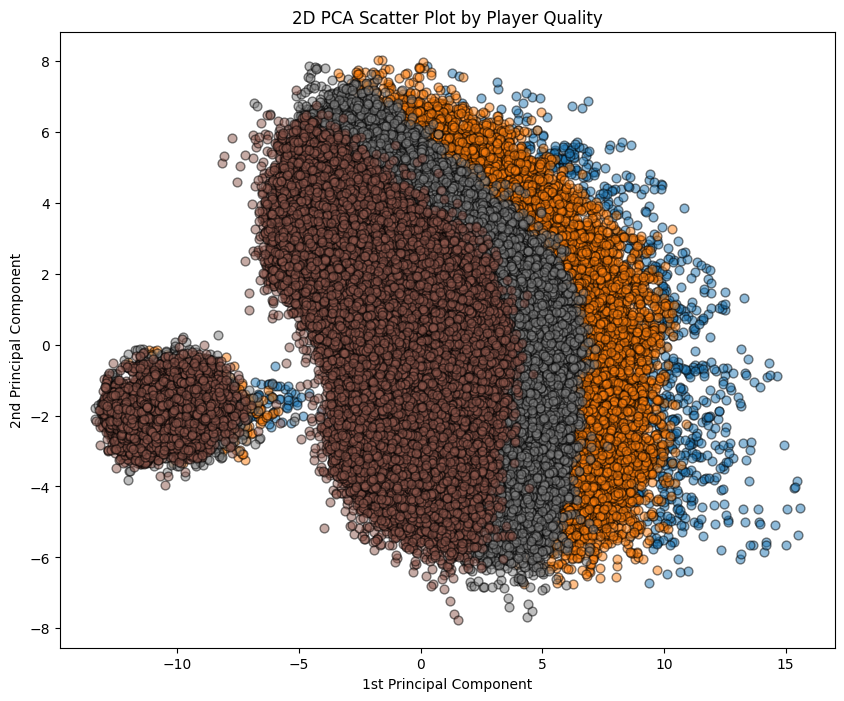

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot2DScatter(X, y_labels):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    fig = plt.figure(figsize=(10, 8))

    categories = ['World Class', 'Top Player', 'Normal Player', 'Bad Player']
    colors = ['tab:blue', 'tab:orange', 'tab:grey', 'tab:brown']

    for category, color in zip(categories, colors):
        plt.scatter(
            X_2d[y_labels == category, 0],
            X_2d[y_labels == category, 1],
            color=color,
            edgecolor='k',
            label=category,
            s=40,
            alpha=0.5
        )

    plt.title("2D PCA Scatter Plot by Player Quality")
    plt.xlabel("1st Principal Component")
    plt.ylabel("2nd Principal Component")
    plt.show()

y_labels = classify_players(y)
plot2DScatter(X_scaled, y_labels)

This 2D scatter plot shows the distribution of players based on the first two principal components obtained from a PCA. Each point represents a player, projected into a lower-dimensional space that captures the most variance in the dataset. The points are colored by player quality categories and we use transparency to highlight areas of high player density.

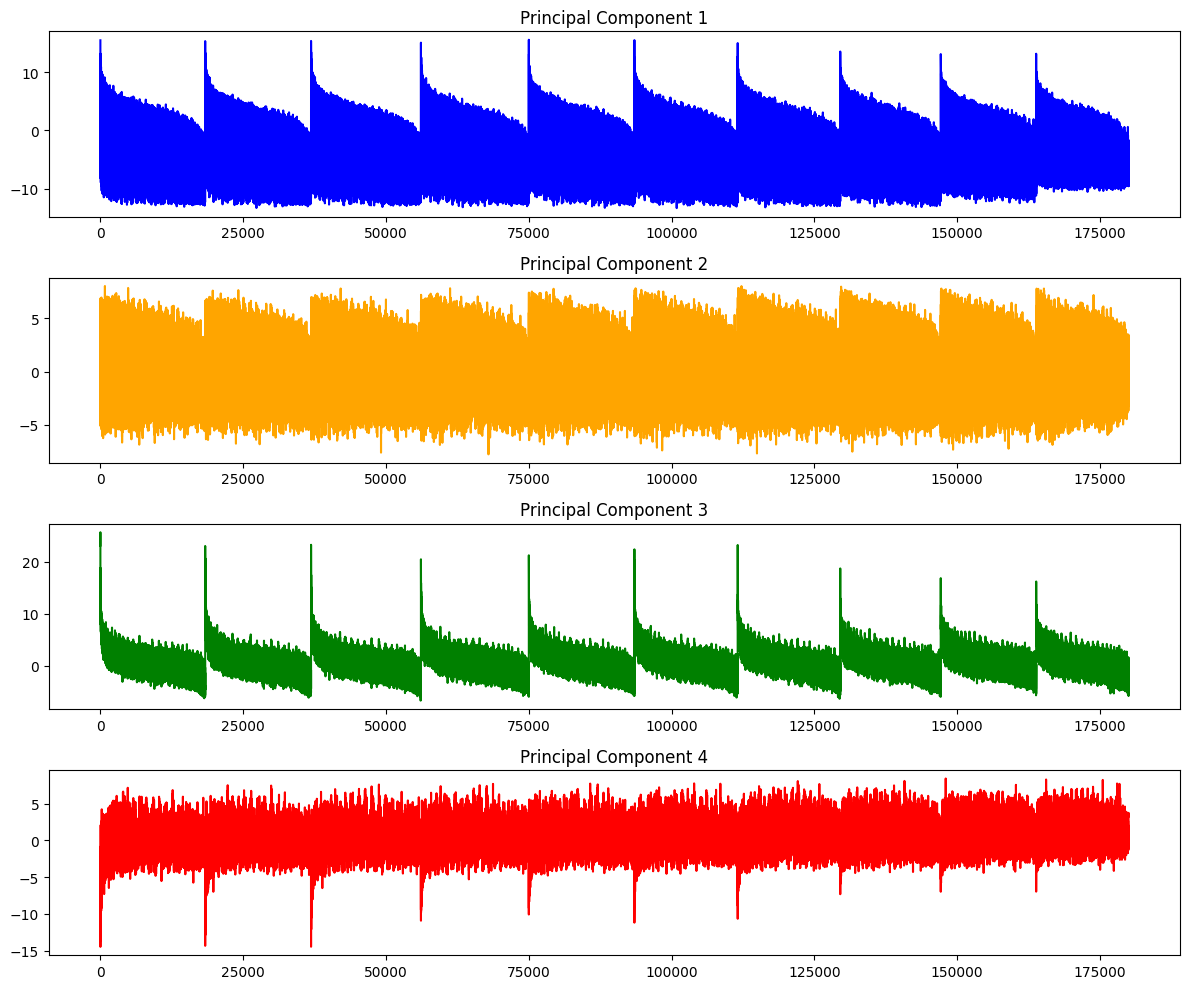

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['PlayerIndex'] = pca_df.index
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

ax = plt.subplot(4, 1, 1)
ax.plot(pca_df['PlayerIndex'], pca_df['PC1'], color='blue')
ax.set_title('Principal Component 1')

ax = plt.subplot(4, 1, 2)
ax.plot(pca_df['PlayerIndex'], pca_df['PC2'], color='orange')
ax.set_title('Principal Component 2')

ax = plt.subplot(4, 1, 3)
ax.plot(pca_df['PlayerIndex'], pca_df['PC3'], color='green')
ax.set_title('Principal Component 3')

ax = plt.subplot(4, 1, 4)
ax.plot(pca_df['PlayerIndex'], pca_df['PC4'], color='red')
ax.set_title('Principal Component 4')

plt.tight_layout()
plt.show()

This plot shows how the first four principal components vary across players. The x-axis represents the player index (row number), and each subplot shows one component. This helps identify trends or anomalies in how players are distributed along the main axes of variance.



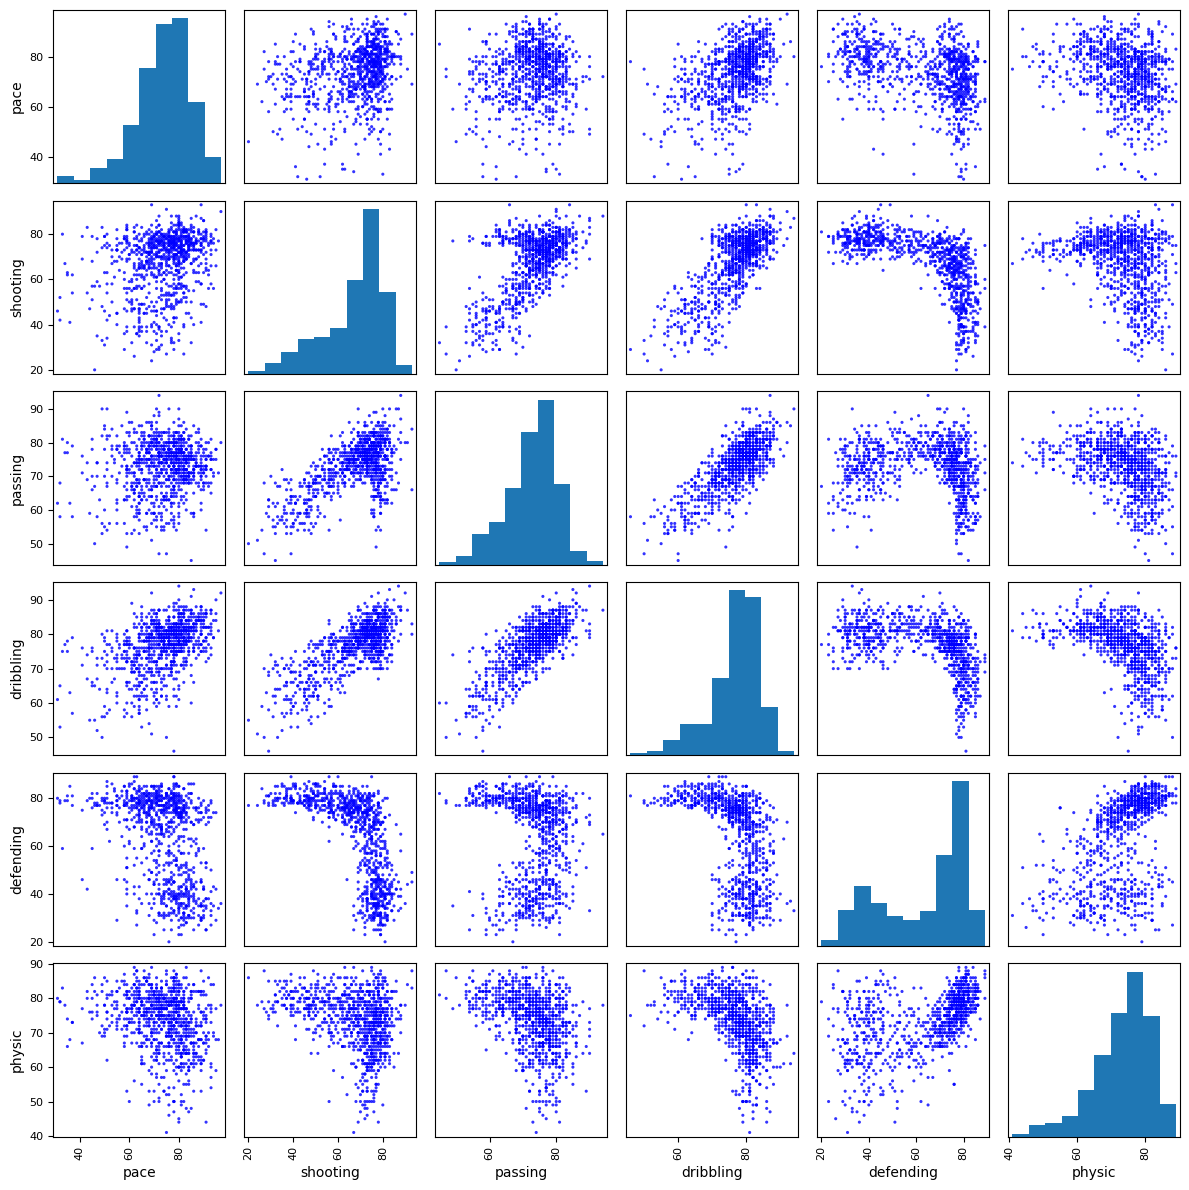

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

subset = players[:1000][['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']]

scatter_matrix(subset, alpha=0.8, figsize=(12, 12), color='blue', marker='o',s=5)

plt.tight_layout()
plt.show()

We choose the first 1000 players, so that we can correctly view all the graphics and what they show us.


# **K-means Clustering on FIFA Male Players**


1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

2. Data Cleaning and Preprocessing

In [ ]:
numerical_data = players.select_dtypes(include=['int64', 'float64'])

numerical_data = numerical_data.fillna(numerical_data.mean(numeric_only=True))

numerical_data.head()

,player_id,fifa_version,fifa_update,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
0,231747,24.0,2.0,91,94,181500000.0,230000.0,24,182,75,...,88.0,26,34,32,13,5,7,11,6,38.7503
1,239085,24.0,2.0,91,94,185000000.0,340000.0,22,195,94,...,87.0,38,47,29,7,14,13,11,7,38.7503
2,192985,24.0,2.0,91,91,103000000.0,350000.0,32,181,75,...,88.0,66,70,53,15,13,5,10,13,38.7503
3,158023,24.0,2.0,90,90,41000000.0,23000.0,36,169,67,...,96.0,20,35,24,6,11,15,14,8,38.7503
4,165153,24.0,2.0,90,90,51000000.0,95000.0,35,185,81,...,90.0,43,24,18,13,11,5,5,7,38.7503


3. Select Features for Clustering

In [ ]:
features = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
X = numerical_data[features]

We choose player performance features that are useful for clustering similar player profiles.

4. Standardize the Data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Standardizing ensures that all features contribute equally to the clustering by removing scale differences.



5. Elbow Method to Find Optimal k

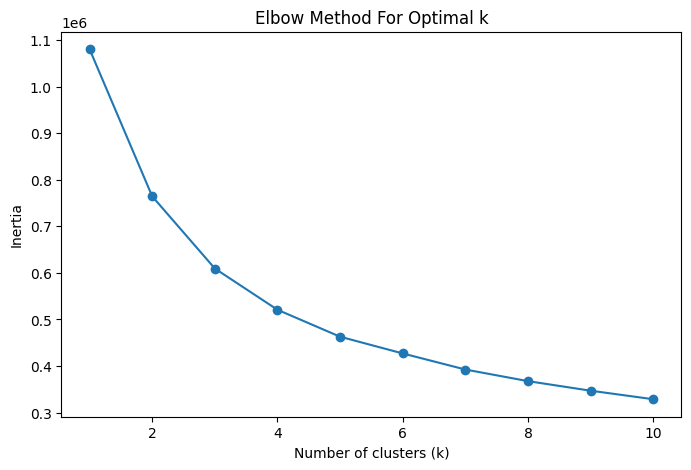

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()



The Elbow method helps determine the ideal number of clusters by observing the point where adding more clusters results in diminishing gains in explained variance.

6. Apply K-means Clustering and visualization

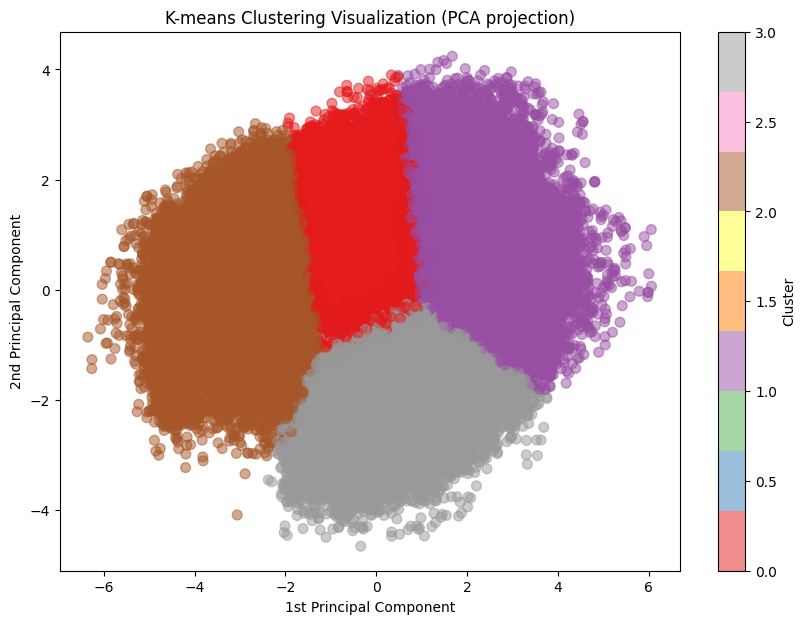

In [ ]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

players['Cluster'] = clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', alpha=0.5, s=50)
plt.xlabel("1st Principal Component")
plt.ylabel("2nd Principal Component")
plt.title("K-means Clustering Visualization (PCA projection)")
plt.colorbar(scatter, label='Cluster')
plt.show()

We use PCA to reduce the dimensionality of the data and visualize how the clusters are distributed in 2D space. Each color represents a different cluster.



7. Cluster Analysis

In [ ]:
players.groupby('Cluster')[features].mean()

,pace,shooting,passing,dribbling,defending,physic
Cluster,,,,,,
0,66.662362,48.712182,59.125003,62.239969,61.836561,68.556809
1,74.238304,66.831991,68.496750,73.136258,51.388418,68.242584
2,57.834026,32.941232,44.381619,47.148788,61.412221,67.404035
3,71.695709,57.664648,53.492057,63.295790,31.134050,55.497162


By analyzing the mean values of features within each cluster, we can interpret the characteristics of each group — such as offensive, defensive, or physically strong players.



# **KNN for Player Quality Prediction**

### 1. Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import seaborn as sns

We begin by importing essential libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), and machine learning (scikit-learn). These provide the tools needed for preprocessing, modeling, and evaluation.

### 2. Loading the Dataset with Error Handling

In [ ]:
def load_football_data(filepath):
    try:
        df = pd.read_csv(filepath, sep=';', engine='python', on_bad_lines='skip')
        required_cols = ['overall', 'potential', 'pace', 'shooting', 'passing',
                         'dribbling', 'defending', 'physic', 'player_positions']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Not enough required columns: {missing_cols}")
        return df
    except Exception as e:
        print(f"Error reading the file: {e}")
        return None

df = load_football_data('male_players_KNN.csv')
if df is None or df.empty:
    raise ValueError("Couldn't load the dataset succesfully")

Error reading the file: [Errno 2] No such file or directory: 'male_players_KNN.csv'


ValueError: Couldn't load the dataset succesfully

A function is defined to load the dataset from a .csv file. It checks for essential columns and handles errors if any required data is missing or malformed. This prevents runtime failures in later stages.

### 3. Preprocessing


In [ ]:
selected_features = [
    'overall', 'potential', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling',
    'defending', 'physic', 'player_positions'
]
df = df[selected_features].copy()

num_cols = ['overall', 'potential', 'height_cm', 'weight_kg',
            'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Quality Classification players
bins = [0, 65, 75, 85, 100]
labels = ['Bad Player', 'Normal Player', 'Top Player', 'World Class']
df['quality_class'] = pd.cut(df['overall'], bins=bins, labels=labels)

# Position's Codification
le = LabelEncoder()
df['player_position_encoded'] = le.fit_transform(df['player_positions'])

We select relevant numerical and categorical features. Non-numeric values are coerced, and missing values are imputed using the median to maintain data integrity. Player quality is classified into four categories, and positions are encoded with LabelEncoder.

###4. Feature Engineering


In [ ]:
df['attack_score'] = (df['shooting'] + df['dribbling'] + df['pace']) / 3
df['defense_score'] = (df['defending'] + df['physic']) / 2
df['skill_balance'] = abs(df['attack_score'] - df['defense_score'])

X = df[['potential', 'height_cm', 'weight_kg',
        'pace', 'shooting', 'passing', 'dribbling',
        'defending', 'physic', 'player_position_encoded',
        'attack_score', 'defense_score', 'skill_balance']]
y = df['quality_class']

New informative features are created to capture offensive (attack_score), defensive (defense_score), and balance-related attributes. These derived variables aim to improve the model's predictive power by summarizing key abilities.

###5. Scaling


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

All features are scaled using StandardScaler to ensure they are on the same scale. This is particularly important for distance-based models like KNN, where unscaled data can bias the results.

### 6. Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

The dataset is split into training and testing subsets using stratified sampling to preserve class distribution. This ensures fair evaluation of the model’s performance across all player quality categories.



### 7. Training without PCA


In [ ]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_search_no_pca = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_no_pca.fit(X_train, y_train)

print(f" Best Parameters (NO PCA): {grid_search_no_pca.best_params_}")
best_knn_no_pca = grid_search_no_pca.best_estimator_

y_pred_no_pca = best_knn_no_pca.predict(X_test)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print(f"\n Accuracy NO PCA: {acc_no_pca:.4f}")
print("\n Report NO PCA:\n", classification_report(y_test, y_pred_no_pca))

# Confusion Matrix NO PCA
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_no_pca),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (NO PCA)')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

A K-Nearest Neighbors classifier is trained using hyperparameter tuning via GridSearchCV. The model is evaluated using classification metrics and a confusion matrix to assess prediction accuracy and class-wise performance. As we are having 5 n_neighbors values, 2 weights options and 2 metric options, we are doing 20 combinations, and because we doing cross validation of 5 partitions (cv=5), that implies we are doing 100 trained and validated models, and because the data set is about 180.000, the execute time for us was between 30 and 40 minutes.

### 8. Training with PCA


In [ ]:
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.25, random_state=42, stratify=y
)

grid_search_pca = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_pca.fit(X_train_pca, y_train_pca)

print(f" Best Parameters (With PCA): {grid_search_pca.best_params_}")
best_knn_pca = grid_search_pca.best_estimator_

y_pred_pca = best_knn_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test_pca, y_pred_pca)
print(f"\n Accuracy With PCA: {acc_pca:.4f}")
print("\n Reporte With PCA:\n", classification_report(y_test_pca, y_pred_pca))

# Confusion Matrix With PCA
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_pca, y_pred_pca),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (With PCA)')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

We apply PCA to reduce the dataset to 6 principal components. A second KNN model is trained on the reduced data and evaluated similarly. This allows us to directly compare performance with and without dimensionality reduction. Because of the big reduction the PCA does into the data, basically reducing the dimensionality to 6 components, so also the computation needed to calculate distances is much faster in lower dimensionality problems. This code had for us an execution time of about 10 minutes.

### 9. Optional PCA 2D Visualization


In [ ]:
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                      c=df['overall'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Overall Rating')
plt.title('Visualization PCA - Football players (2D)')
plt.xlabel(f'Component 1 ({pca_vis.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Component 2 ({pca_vis.explained_variance_ratio_[1]:.1%})')
plt.tight_layout()
plt.show()

The first two PCA components are used to create a 2D scatter plot of players, colored by their overall rating. This visual helps assess how well the principal components separate players based on performance.

### 10. Comparative Plot


In [ ]:
labels_modelos = ['NO PCA', 'With PCA']
scores = [acc_no_pca, acc_pca]

plt.figure(figsize=(6, 5))
plt.bar(labels_modelos, scores, color=['steelblue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Comparation: KNN with and without PCA')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

A bar chart shows the accuracy of the KNN model with and without PCA. This visual summary highlights the impact of dimensionality reduction on classification performance and helps determine the better approach.

From the previous executions, we got this diference:

 Accuracy NO PCA: 0.9002

 Accuracy With PCA: 0.8766

The diference in accuracy we are getting between using PCA and not using it is about 0.03 (3%). So, we can say in conclusion that for the small diference we are getting in accuracy, but the big one we are getting when talking about computation costs and time, using PCA saves a lot of resources, having very similar performance with a much lower computational cost.

# **Recommender System**



We import the necessary libraries and we read the dataset

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# We load the dataset
df = pd.read_csv("male_players.csv", low_memory=False)
# As there are different versions for each player in the dataset we only keep the latest version so we avoid duplicates
df = df.sort_values(by='fifa_update', ascending=False)
df = df.drop_duplicates(subset='player_id', keep='first')

## Recommender System to search for similar players

### Search for a Mbappé regen

In [ ]:
#We select the important statistics related to Mbappe's playing style
features = ['pace', 'shooting', 'dribbling', 'passing', 'physic', 'overall', 'skill_moves','potential']
data = df[['short_name'] + features].dropna()


data.set_index('short_name', inplace=True)


mbappe_vector = data.loc["K. Mbappé"]
similarities = data.corrwith(mbappe_vector, axis=1)


similarities = similarities.drop("K. Mbappé")
top_similar = similarities.sort_values(ascending=False).head(10)
top_similar.head(10)

In this case we try to find the similarity with Pearson correlation.

In [ ]:
df = df.sort_values(by='fifa_update', ascending=False)
df = df.drop_duplicates(subset='player_id', keep='first')


df_cm = df[df['player_positions'].str.contains('CM', na=False)]

features = ['pace', 'shooting', 'dribbling', 'passing', 'physic', 'overall', 'skill_moves','potential',]


Mbappe_data = df[['short_name'] + features].dropna()
Mbappe_data.set_index('short_name', inplace=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(Mbappe_data)


target_name = "K. Mbappé"
target_vector = X_scaled[Mbappe_data.index.get_loc(target_name)].reshape(1, -1)


similarities = cosine_similarity(target_vector, X_scaled).flatten()
Mbappe_data['similarity'] = similarities


similar_Mbappe = Mbappe_data.drop(index=target_name).sort_values(by='similarity', ascending=False)
similar_Mbappe.head(10)

As we can see, here we try to do it with cosine_similarity and we can see the difference on the recommended players.

### Find similar goalkeepers to Courtois

In [ ]:
gk_df = df[df['player_positions'].str.contains('GK', na=False)]

# Features specific to goalkeepers
gk_features = [
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
    'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed','overall','potential'
]


gk_data = gk_df[['short_name'] + gk_features].dropna()
gk_data.set_index('short_name', inplace=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(gk_data)


target_name = "T. Courtois"
target_vector = X_scaled[gk_data.index.get_loc(target_name)].reshape(1, -1)


similarities = cosine_similarity(target_vector, X_scaled).flatten()

gk_data['similarity'] = similarities


similar_gks = gk_data.drop(index=target_name).sort_values(by='similarity', ascending=False).head(10)

similar_gks.head(10)

We show graphically the top 10 most similar players to Courtois.

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(similar_gks.index, similar_gks['similarity'], color='lightgreen')
plt.xlabel("Cosine Similarity")
plt.title(f"Top Goalkeepers Similar to {target_name}")
plt.xlim(0.95, 1.0)
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

### Similar players to De Bruyne

Now we pick the best CM in EA FC 24 to find the top 10 most similar players

In [ ]:
df_cm = df[df['player_positions'].str.contains('CM', na=False)]


features_cm = ['pace', 'shooting', 'physic', 'overall', 'skill_moves','potential',
    'passing', 'mentality_vision', 'attacking_short_passing',
    'skill_ball_control', 'skill_long_passing', 'dribbling',
    'power_stamina', 'movement_reactions']


cm_data = df_cm[['short_name'] + features_cm].dropna()
cm_data.set_index('short_name', inplace=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(cm_data)


target_name = "K. De Bruyne"
target_vector = X_scaled[cm_data.index.get_loc(target_name)].reshape(1, -1)


similarities = cosine_similarity(target_vector, X_scaled).flatten()
cm_data['similarity'] = similarities


similar_cm = cm_data.drop(index=target_name).sort_values(by='similarity', ascending=False)
similar_cm.head(10)

In this case we've used specific statistics that make De Bruyne special like mentality vision or skill ball control.

## Recommender System for user collaborative filtering

In [ ]:
# We convert club joined date to datetime
df['club_joined_date'] = pd.to_datetime(df['club_joined_date'], errors='coerce')

### Brighton transfer profile as an user

In [ ]:
features = ['age', 'overall', 'potential', 'pace', 'dribbling', 'passing', 'physic', 'defending']
features = [f for f in features if f in df.columns]


df = df.dropna(subset=features + ['club_name'])


# Brighton signings since 2019
brighton_signings = df[
    (df['club_name'].str.contains("Brighton", case=False, na=False)) &
    (df['club_joined_date'] > '2019-01-01')
].copy()

df_all = df.copy()

scaler = StandardScaler()
X_all = scaler.fit_transform(df_all[features])

 #Brighton profile as a user
brighton_scaled = scaler.transform(brighton_signings[features])
brighton_profile = brighton_scaled.mean(axis=0).reshape(1, -1)


similarities = cosine_similarity(brighton_profile, X_all).flatten()
df_all['similarity_to_brighton'] = similarities

# We remove Brighton players from recommendations
df_all = df_all[~df_all['club_name'].str.contains("Brighton", case=False, na=False)]

# 11. Filter to simulate realistic Brighton targets as they look under the radar young players
candidates = df_all[
    (df_all['age'] <= 23) &
    (df_all['overall'] <= 78) &
    (df_all['potential'] >= 83) &
    (df_all['value_eur'] < 25_000_000)
]


top_brighton_targets = candidates.sort_values(by='similarity_to_brighton', ascending=False).head(10)


top_brighton_targets[['short_name', 'age', 'club_name', 'overall', 'potential', 'value_eur', 'similarity_to_brighton']].head(10)

We have used Brighton as a user, the transfer history as a preference and the players similar to brighton transfers as items.


Brighton is known because they're use of big data in their signing policy so we choose them

### Interactive user collaborative filtering with club as users and players as items

In [ ]:
#In order to show the results correctly
from IPython.display import display

Now following the Brighton example we also decided to do a dynamic user collaborative filtering making four club cathegories with different items characteristics.

The categories we made are: World class tier, great team tier, smart recuitment tier and humble club tier

In [ ]:

club_name = input("Enter the club name (for example Barcelona, Inter, Girona, Huesca...): ").strip().lower()

features = ['age', 'overall', 'potential', 'skill_moves', 'pace', 'dribbling', 'passing',
            'physic', 'defending', 'composure', 'shooting', 'stamina']
features = [f for f in features if f in df.columns]
df = df.dropna(subset=features + ['club_name'])

# We define club categories
world_class_clubs = ['barcelona', 'real madrid', 'manchester city', 'bayern münchen', 'manchester united', 'paris saint germain', 'liverpool']

good_clubs = ['dortmund', 'atletico madrid', 'chelsea', 'arsenal', 'ac milan', 'inter', 'napoli', 'leverkusen', 'juventus', 'tottenham']

underdog_clubs = ['brighton', 'brentford', 'bologna', 'atalanta', 'ajax','fulham', 'real sociedad', 'girona', 'rb leipzig','sevilla']

humble_clubs = ['huesca', 'eibar', 'espanyol', 'heidenheim', 'cádiz', 'albacete', 'sunderland', 'levante', 'arminia bielefeld']


all_clubs = world_class_clubs + good_clubs + underdog_clubs + humble_clubs
if club_name not in all_clubs:
    print("Invalid club name. Please try again.")
    exit()

# Dynamic filters by club tier
if club_name in world_class_clubs:
    age_min, age_max = 16, 27
    overall_min, potential_min = 80, 85
    overall_max = potential_max = None
    tier = " World class tier"

elif club_name in good_clubs:
    age_min, age_max = 16, 25
    overall_min, potential_min = 78, 83
    overall_max = potential_max = None
    tier = " Great team tier"

elif club_name in underdog_clubs:
    age_min, age_max = 16, 23
    potential_min = 82
    overall_min = None
    overall_max = 80
    potential_max = None
    tier = " Smart recruitment tier"

else:
    age_min, age_max = 23, 30
    overall_min = potential_min = None
    overall_max, potential_max = 75, 80
    tier = " Humble club tier"

print(f"\n Team choosen from {tier} is {club_name.title()}")

# Get club signings
club_signings = df[
    (df['club_name'].str.lower().str.contains(club_name)) &
    (df['club_joined_date'] > '2019-01-01')
].copy()

if club_signings.empty:
    print(f" No recent signings found for '{club_name.title()}'. Try another club.")
    exit()


scaler = StandardScaler()
X_all = scaler.fit_transform(df[features])
X_club = scaler.transform(club_signings[features])
club_profile = X_club.mean(axis=0).reshape(1, -1)


similarities = cosine_similarity(club_profile, X_all).flatten()
df = df.copy()
df['similarity_to_club'] = similarities


df_filtered = df[~df['club_name'].str.lower().str.contains(club_name)].copy()


candidates = df_filtered[
    (df_filtered['age'] >= age_min) &
    (df_filtered['age'] <= age_max)
]
if overall_min is not None:
    candidates = candidates[candidates['overall'] >= overall_min]
if overall_max is not None:
    candidates = candidates[candidates['overall'] <= overall_max]
if potential_min is not None:
    candidates = candidates[candidates['potential'] >= potential_min]
if potential_max is not None:
    candidates = candidates[candidates['potential'] <= potential_max]


top_targets = candidates.sort_values(by='similarity_to_club', ascending=False).head(10)


print(f"\n Top 10 recommended players for {club_name.title()} in {tier}:")
display(
    top_targets[['short_name', 'age', 'club_name', 'overall', 'potential', 'value_eur', 'similarity_to_club']]
    .style
    .background_gradient(cmap="Blues", subset=['similarity_to_club'])
    .format({'value_eur': '€{:,.0f}', 'similarity_to_club': '{:.3f}'})
)




Enter the club name (for example Barcelona, Inter, Girona, Huesca...): Inter


NameError: name 'df' is not defined

We plot the results

In [ ]:

plt.figure(figsize=(10, 6))
plt.barh(top_targets['short_name'], top_targets['similarity_to_club'], color='turquoise')
plt.xlabel("Cosine Similarity")
plt.title(f"Top 10 Players Similar to {club_name.title()}'s Transfer Profile")
plt.gca().invert_yaxis()
plt.xlim(0.8,1)
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

NameError: name 'top_targets' is not defined

<Figure size 1000x600 with 0 Axes>

## Recommender system for a new player in the dataset

We find its value and the most similar players

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
# Load and clean only ONCE
df_original = pd.read_csv("male_players.csv", low_memory=False)
df_original = df_original.sort_values(by='fifa_update', ascending=False)
df_original = df_original.drop_duplicates(subset='player_id', keep='first')

In [ ]:
new_player_name = input("Enter the name of the new player: ")
target_position = input("Position options: GK, CB, RB, LB, CDM, CM, CAM, ST, LW, RW: ").strip().upper()

# Define features depending on position
if target_position == 'GK':
    features = [
        'age', 'overall', 'potential',
        'goalkeeping_diving', 'goalkeeping_handling',
        'goalkeeping_kicking', 'goalkeeping_positioning',
        'goalkeeping_reflexes', 'goalkeeping_speed'
    ]
else:
    features = [
        'age', 'overall', 'potential',
        'pace', 'shooting', 'passing',
        'dribbling', 'defending', 'physic'
    ]


df = df_original.copy()


df = df.dropna(subset=features + ['value_eur', 'player_positions'])


df = df[df['player_positions'].str.upper().str.contains(target_position)].copy()


if df.empty:
    print(f"No players found for position: {target_position}. Please try again.")
    exit()

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

# Input player stats
print(f"\nEnter stats for new {target_position} player:")

if target_position == 'GK':
    new_player = {
        'age': int(input("Age: ")),
        'overall': int(input("Overall: ")),
        'potential': int(input("Potential: ")),
        'goalkeeping_diving': int(input("Goalkeeping diving: ")),
        'goalkeeping_handling': int(input("Goalkeeping handling: ")),
        'goalkeeping_kicking': int(input("Goalkeeping kicking: ")),
        'goalkeeping_positioning': int(input("Goalkeeping positioning: ")),
        'goalkeeping_reflexes': int(input("Goalkeeping reflexes: ")),
        'goalkeeping_speed': int(input("Goalkeeping speed: "))
    }
else:
    new_player = {
        'age': int(input("Age: ")),
        'overall': int(input("Overall: ")),
        'potential': int(input("Potential: ")),
        'pace': int(input("Pace: ")),
        'shooting': int(input("Shooting: ")),
        'passing': int(input("Passing: ")),
        'dribbling': int(input("Dribbling: ")),
        'defending': int(input("Defending: ")),
        'physic': int(input("Physic: "))
        }


new_df = pd.DataFrame([new_player])
new_scaled = scaler.transform(new_df)



similarities = cosine_similarity(new_scaled, X).flatten()
df['similarity'] = similarities

top_similar = df.sort_values(by='similarity', ascending=False).head(10)

# Estimate market value
estimated_value = top_similar['value_eur'].mean()

print(f"\n Estimated market value of {new_player_name}: €{estimated_value:,.0f}")
print(f"\n Most similar players to {new_player_name}:\n")
display(top_similar[['short_name', 'age', 'overall', 'potential', 'value_eur', 'similarity']])

Enter the name of the new player: Diego
Position options: GK, CB, RB, LB, CDM, CM, CAM, ST, LW, RW: CAM

Enter stats for new CAM player:
Age: 18
Overall: 88
Potential: 93
Pace: 86
Shooting: 80
Passing: 80
Dribbling: 92


In [ ]:
#We sort the players and we round its value
top_similar_sorted = top_similar.sort_values(by='value_eur', ascending=True).copy()
top_similar_sorted['value_millions'] = (top_similar_sorted['value_eur'] / 1_000_000).round(2)

plt.figure(figsize=(10, 6))
plt.barh(top_similar_sorted['short_name'], top_similar_sorted['value_millions'], color='orange')
plt.xlabel("Market Value (€M)")
plt.title(f"Top 10 most similar players to {new_player_name} and their market value")
plt.grid(axis='x')
plt.tight_layout()
plt.show()